# Classification program only

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import cv2

## Load in the data
Useful functions and data load


In [2]:
def get_data(dataset,X,num=-1,augment=False,sobel=True,printer="resin",filament="resin",pressure="P30",pattern="",augtests=[]):
    subset = dataset[((dataset['Printer'] == printer) & (dataset['Filament']==filament)) ]
    if pattern!="":
        subset = subset[subset['Pattern'].str.contains(pattern, regex=False, na=False) ]
    subX, y = [], []
    for _, row in subset.iterrows():
        images=X[int(row['Index'])]
        images=images.reshape((2*25,images.shape[2],images.shape[3]))
        try:
            label=int(row['Pattern'].split(".")[0].replace("z", ""))
        except:
            label=""
        if label!="":
            for image in images:
                if sobel:
                    # Apply Sobel filter (on grayscale if not already)
                    if len(image.shape) == 3:  # convert to grayscale if it's RGB
                        roi_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    else:
                        roi_gray = image

                    sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
                    sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)

                    sobel_ = np.hypot(sobelx, sobely)  # magnitude
                    image = cv2.convertScaleAbs(sobel_)  # scale back to uint8
                if num==-1:
                    y.append(label)
                    subX.append(image)
                else: 
                    try:
                        counter=int(row['Pattern'].split(".")[1])
                        if counter==num:
                            y.append(label)
                            subX.append(image)
                    except:
                        pass
    subX,y=np.array(subX),np.array(y)
    if augment:
        if len(augtests)==0 or 0 in augtests:
            noisy=subX+np.random.normal(0,5,subX.shape)
            subX=np.concatenate([subX,noisy])
            y=np.concatenate([y,y])
        if len(augtests)==1 or 1 in augtests:
            light=subX.copy()-10
            dark=subX.copy()+10
            light[light<0]=0
            dark[dark>255]=255
            subX=np.concatenate([subX,light,dark])
            y=np.concatenate([y,y,y])
    assert len(subX)==len(y) 
    return subX,y

def coral_align_target_to_source(Xs, Xt, eps=1e-6):
    # center
    mu_s = Xs.mean(axis=0, keepdims=True)
    mu_t = Xt.mean(axis=0, keepdims=True)
    Xs_c = Xs - mu_s
    Xt_c = Xt - mu_t

    # covariances with small ridge
    cov_s = np.cov(Xs_c, rowvar=False) + np.eye(Xs_c.shape[1]) * eps
    cov_t = np.cov(Xt_c, rowvar=False) + np.eye(Xt_c.shape[1]) * eps

    # matrix square-roots via SVD
    Us, Ss, _ = np.linalg.svd(cov_s)
    Ut, St, _ = np.linalg.svd(cov_t)
    # cov_s^{1/2} and cov_t^{-1/2}
    cov_s_sqrt = Us @ np.diag(np.sqrt(Ss)) @ Us.T
    cov_t_inv_sqrt = Ut @ np.diag(1.0/np.sqrt(St)) @ Ut.T

    # transform target: Xt_aligned = (Xt_c @ cov_t^{-1/2}) @ cov_s^{1/2} + mu_s
    Xt_aligned = (Xt_c @ cov_t_inv_sqrt) @ cov_s_sqrt + mu_s
    return Xt_aligned

X=np.load("/home/dexter/Documents/GitHub/3D-textures/Experimental/data/X.npy")
dataset=pd.read_csv("/home/dexter/Documents/GitHub/3D-textures/Experimental/datameta.csv")
print("Dataset size:",X.shape)
print(len(dataset['Filament'].unique()),len(dataset['Printer'].unique()))
printers=[["resin","resin"],["ender","PLAplus"],["bambu","PLAminus"],]

Dataset size: (204, 2, 25, 192, 256)
5 7


## Classification 
All classification uses PCA
### RFC


In [ ]:
comb=printers[0]
#X_,y_=get_data(dataset,X)
X_2,y_2=get_data(dataset,X,printer=comb[0],filament=comb[1],num=1,augment=True)
X_3,y_3=get_data(dataset,X,printer=comb[0],filament=comb[1],)
#print(X_.shape,X_2.shape,X_3.shape,y_.shape,y_2.shape,y_3.shape)
#X_=X_.reshape((len(X_),-1))
X_2=X_2.reshape((len(X_2),-1))
X_3=X_3.reshape((len(X_3),-1))
print(X_2.shape,y_2.shape)
pca = PCA(n_components=25).fit(X_2)
Z_train = pca.transform(X_2)  # (N,3)
#Z_test = pca.transform(X_)
Z_test = pca.transform(X_3)
#Z_test = np.concatenate([Z_test,Z_test2])
y_=y_3
#Z_test=coral_align_target_to_source(Z_train, Z_test)
#selet just one and train classifier
acc=np.zeros((20))
train=np.zeros((20))
test=np.zeros((20))
for i in range(20):
    clf = RandomForestClassifier(max_depth=50, random_state=np.random.randint(0,100))
    train_X, test_X, train_y, test_y = train_test_split(Z_train,y_2)
    clf.fit(train_X, train_y)
    y_pred = clf.predict(train_X)
    accuracy = accuracy_score(train_y, y_pred)
    train[i]=accuracy*100
    y_pred = clf.predict(test_X)
    accuracy = accuracy_score(test_y, y_pred)
    test[i]=accuracy*100
    # select all the others and test classifier
    y_pred = clf.predict(Z_test)
    accuracy = accuracy_score(y_, y_pred)
    acc[i]=accuracy*100
print("Other",np.mean(acc), "%",np.std(acc))
print("Train",np.mean(train), "%",np.std(train))
print("Test",np.mean(test), "%",np.std(test))

In [ ]:
X_sub2,y_sub2=get_data(dataset,X,printer="resin",filament="resin",augment=True,pattern=".2")
X_sub2=X_sub2.reshape((len(X_sub2),-1))
test_X = pca.transform(X_sub2)
y_pred = clf.predict(test_X)
cm = confusion_matrix(y_sub2, y_pred) #,label=np.unique(test_y)
class_labels = ["Texture "+str(i+1) for i in range(6)]

# plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

# Increase font sizes
ax.set_title("Confusion Matrix", fontsize=20)
ax.set_xlabel("Predicted label", fontsize=16)
ax.set_ylabel("True label", fontsize=16)

ax.tick_params(axis='x', labelsize=14,rotation=45)
ax.tick_params(axis='y', labelsize=14)

plt.savefig("/home/dexter/Documents/GitHub/3D-textures/assets/confusion_RFC_resin.pdf",
            bbox_inches="tight")
plt.show()

### ANN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleANN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleANN, self).__init__()
        # Input layer to hidden layer
        self.fc1 = nn.Linear(input_size, hidden_size)
        # Hidden layer to hidden layer (optional)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        # Hidden layer to output layer
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self, x):
        # Apply ReLU activation for hidden layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        # Output layer (no activation if using CrossEntropyLoss)
        x = self.fc3(x)
        return x

def train_model(train_X, train_y, test_X, test_y, params, epochs=100, batch_size=32,arch=None,):
    # Permute to (N, C, H, W)
    # Convert to torch tensors
    train_X = torch.tensor(train_X, dtype=torch.float32)
    test_X = torch.tensor(test_X, dtype=torch.float32)
    train_y = torch.tensor(train_y)
    test_y = torch.tensor(test_y)

    train_dataset = TensorDataset(train_X, train_y)
    test_dataset = TensorDataset(test_X, test_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = arch(*params).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    for epoch in range(epochs):
        #model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            X_batch=X_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.to(device))
            loss.backward()
            optimizer.step()
            torch.cuda.empty_cache()
        if epoch%500==0: print("Epoch",epoch," loss:",loss.item())

    # Evaluate
    def evaluate(loader):
        model.eval()
        correct, total, running_loss = 0, 0, 0.0
        with torch.no_grad():
            for X_batch, y_batch in loader:
                outputs = model(X_batch.to(device))
                loss = criterion(outputs, y_batch.to(device))
                running_loss += loss.item()
                predicted = torch.argmax(outputs.cpu(), axis=1)
                correct += (predicted == torch.argmax(y_batch, axis=1)).sum().item()
                total += y_batch.size(0)
        return running_loss / len(loader), correct / total

    test_loss, test_acc = evaluate(test_loader)
    train_loss, train_acc = evaluate(train_loader)
    return model, train_acc, test_acc

# ------------------------------------------------------------------
# Dataset splitting helpers
# ------------------------------------------------------------------


def get_y(y, num_classes):
    unique_labels = np.arange(num_classes)
    label_map = {label: i for i, label in enumerate(unique_labels)}
    y_mapped = np.array([label_map.get(l, -1) for l in y])
    y_cat = np.eye(num_classes)[y_mapped]
    return y_cat


In [ ]:
from sklearn.decomposition import PCA

#X_,y_=get_data(dataset,X)
X_2,y_2=get_data(bambu_dataset,bambu_X,num=1,augment=True)
X_3,y_3=get_data(bambu_dataset,bambu_X)
#print(X_.shape,X_2.shape,X_3.shape,y_.shape,y_2.shape,y_3.shape)
#X_=X_.reshape((len(X_),-1))
X_2=X_2.reshape((len(X_2),-1))
X_3=X_3.reshape((len(X_3),-1))
#print(X_.shape,X_2.shape,y_.shape,y_2.shape)
pca = PCA(n_components=45).fit(X_2)
Z_train = pca.transform(X_2)  # (N,3)
#Z_test = pca.transform(X_)
Z_test = pca.transform(X_3)
#Z_test = np.concatenate([Z_test,Z_test2])
y_=y_3#np.concatenate([y_,y_3])

acc=[]
for i in range(20):
    #train_X, test_X, train_y, test_y = train_test_split(Z_train.astype('float32'), y_2, test_size=0.2, random_state=np.random.randint(0,100))
    mean_train = Z_train.mean(axis=0)
    mean_other = Z_test.mean(axis=0)
    #Z_test = Z_test - (mean_other - mean_train)
    Z_train=(Z_train-np.min(Z_train))/(np.max(Z_train)-np.min(Z_train))
    Z_test=(Z_test-np.min(Z_test))/(np.max(Z_test)-np.min(Z_test))
    model, train_acc, test_acc = model, train_acc, test_acc = train_model(
                                Z_train.astype('float32'), get_y(y_2,6), Z_test.astype('float32'), get_y(y_,6), (Z_train.shape[1],50,6), epochs=15000,batch_size=64, arch=SimpleANN)
    torch.cuda.empty_cache()
    acc.append([train_acc,test_acc])   
    print("Running avg:",np.average(np.array(acc),axis=0))  
acc=np.array(acc)
np.save("/its/home/drs25/3D-textures/Experimental/data/ANN_resin_e15000",acc)   
print(np.average(acc,axis=0))  

## Data augmentation and abliation

In [11]:
# just train once
#X_=X.reshape((130*2*25,192,256))
PRINTER="bambu"
FILAMENT="PLAminus"
acc_unseen=[]
std=[]
for test in [[-1],[0],[1],[]]:
    t=[]
    for i in range(20):
        X_sub,y_sub=get_data(dataset,X,printer=PRINTER,filament=FILAMENT,augment=True,pattern=".2",augtests=test)
        #print(X_sub.shape)
        X_sub=X_sub.reshape((len(X_sub),-1))
        train_X, test_X, train_y, test_y = train_test_split(X_sub,y_sub)
        pca = PCA(n_components=25).fit(train_X)
        train_X=pca.transform(train_X)
        test_X = pca.transform(test_X)
        clf = RandomForestClassifier(max_depth=50, random_state=np.random.randint(0,100))
        clf.fit(train_X, train_y)
        y_pred = clf.predict(test_X)
        accuracy = accuracy_score(test_y, y_pred)
        #print("Test",accuracy*100, "%",end="")
        X_sub2,y_sub2=get_data(dataset,X,printer=PRINTER,filament=FILAMENT,augment=True,pattern=".1")
        X_sub2=X_sub2.reshape((len(X_sub2),-1))
        test_X = pca.transform(X_sub2)
        y_pred = clf.predict(test_X)
        t.append(accuracy_score(y_sub2, y_pred))
    print("Average accuracy:",np.average(np.array(t)),"STD:",np.std(np.array(t)))
    std.append(np.std(np.array(t)))
    acc_unseen.append(t)
    
"""
subX,y=np.array(subX),np.array(y)
    if augment:
        if len(augtests)==0 or 0 in augtests:
            noisy=subX+np.random.normal(0,5,subX.shape)
            subX=np.concatenate([subX,noisy])
            y=np.concatenate([y,y])
        if len(augtests)==1 or 1 in augtests:
            light=subX.copy()-10
            dark=subX.copy()+10
            light[light<0]=0
            dark[dark>255]=255
            subX=np.concatenate([subX,light,dark])
            y=np.concatenate([y,y,y])
"""


Average accuracy: 0.8952500000000001 STD: 0.01998106742783167
Average accuracy: 0.9165833333333335 STD: 0.0173563549040562
Average accuracy: 0.8950833333333333 STD: 0.020746318281136596
Average accuracy: 0.9024166666666666 STD: 0.021937252689330885


'\nsubX,y=np.array(subX),np.array(y)\n    if augment:\n        if len(augtests)==0 or 0 in augtests:\n            noisy=subX+np.random.normal(0,5,subX.shape)\n            subX=np.concatenate([subX,noisy])\n            y=np.concatenate([y,y])\n        if len(augtests)==1 or 1 in augtests:\n            light=subX.copy()-10\n            dark=subX.copy()+10\n            light[light<0]=0\n            dark[dark>255]=255\n            subX=np.concatenate([subX,light,dark])\n            y=np.concatenate([y,y,y])\n'

### PCA stuff

In [ ]:
pca = PCA()
X_sub,y_sub=get_data(dataset,X,printer=PRINTER,filament=FILAMENT,augment=True,pattern=".1",augtests=test)
X_sub=X_sub.reshape((len(X_sub),-1))
pca.fit(X_sub)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative PCA Explained Variance")

plt.axhline(y=0.95, color='r', linestyle='--', label="95% variance")
plt.axhline(y=0.99, color='g', linestyle='--', label="99% variance")

plt.legend()
plt.grid()
plt.show()

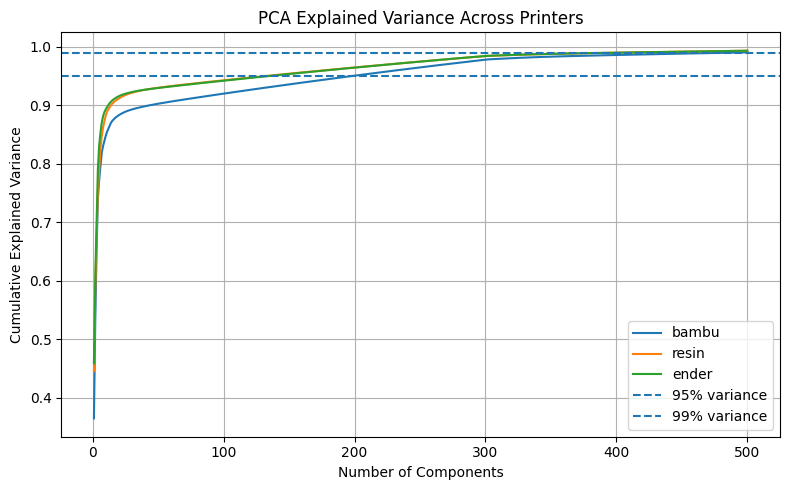

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

printers = ["bambu", "resin","ender"]  # replace with your names
fil = ["PLAminus", "resin","PLAplus"]  # replace with your names

plt.figure(figsize=(8,5))

for i,printer in enumerate(printers):
    
    X_sub, y_sub = get_data(
        dataset,
        X,
        printer=printer,
        filament=fil[i],
        augment=True,
        pattern=".1",
        augtests=[0]
    )

    # flatten images if required
    X_sub = X_sub.reshape(len(X_sub), -1)

    pca = PCA()
    pca.fit(X_sub)

    cumulative_variance = np.cumsum(
        pca.explained_variance_ratio_
    )

    plt.plot(
        range(1, 501), #len(cumulative_variance)+1
        cumulative_variance[:500],
        label=printer
    )


plt.axhline(
    y=0.95,
    linestyle='--',
    label="95% variance"
)

plt.axhline(
    y=0.99,
    linestyle='--',
    label="99% variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Across Printers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("/home/dexter/Documents/GitHub/3D-textures/assets/PCA_Explained.pdf")
plt.show()